<a href="https://colab.research.google.com/github/coder-Basundhara/Inhouse-training-projects/blob/main/InhouseIntershipselfproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt


In [5]:
from google.colab import files
uploaded = files.upload()


Saving Ecommerce Customers.csv to Ecommerce Customers (1).csv


In [6]:
df = pd.read_csv("Ecommerce Customers.csv")
df.head()


,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [7]:
df = df.drop(columns=["Email", "Address"])
df.head()


,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [8]:
X = df.drop("Yearly Amount Spent", axis=1)
y = df["Yearly Amount Spent"]


In [9]:
categorical_features = ["Avatar"]
numerical_features = [
    "Avg. Session Length",
    "Time on App",
    "Time on Website",
    "Length of Membership"
]


In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [12]:
dt = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)


In [13]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("decision_tree", dt)
])


In [14]:
model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Avatar']),
                                                 ('num', 'passthrough',
                                                  ['Avg. Session Length',
                                                   'Time on App',
                                                   'Time on Website',
                                                   'Length of Membership'])])),
                ('decision_tree',
                 DecisionTreeRegressor(max_depth=5, min_samples_leaf=5,
                                       min_samples_split=10,
                                       random_state=42))])

In [15]:
y_pred = model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2  :", r2_score(y_test, y_pred))


MAE : 26.10849998003175
MSE : 1131.6524763229706
RMSE: 33.640042751503316
R2  : 0.7714632505699441


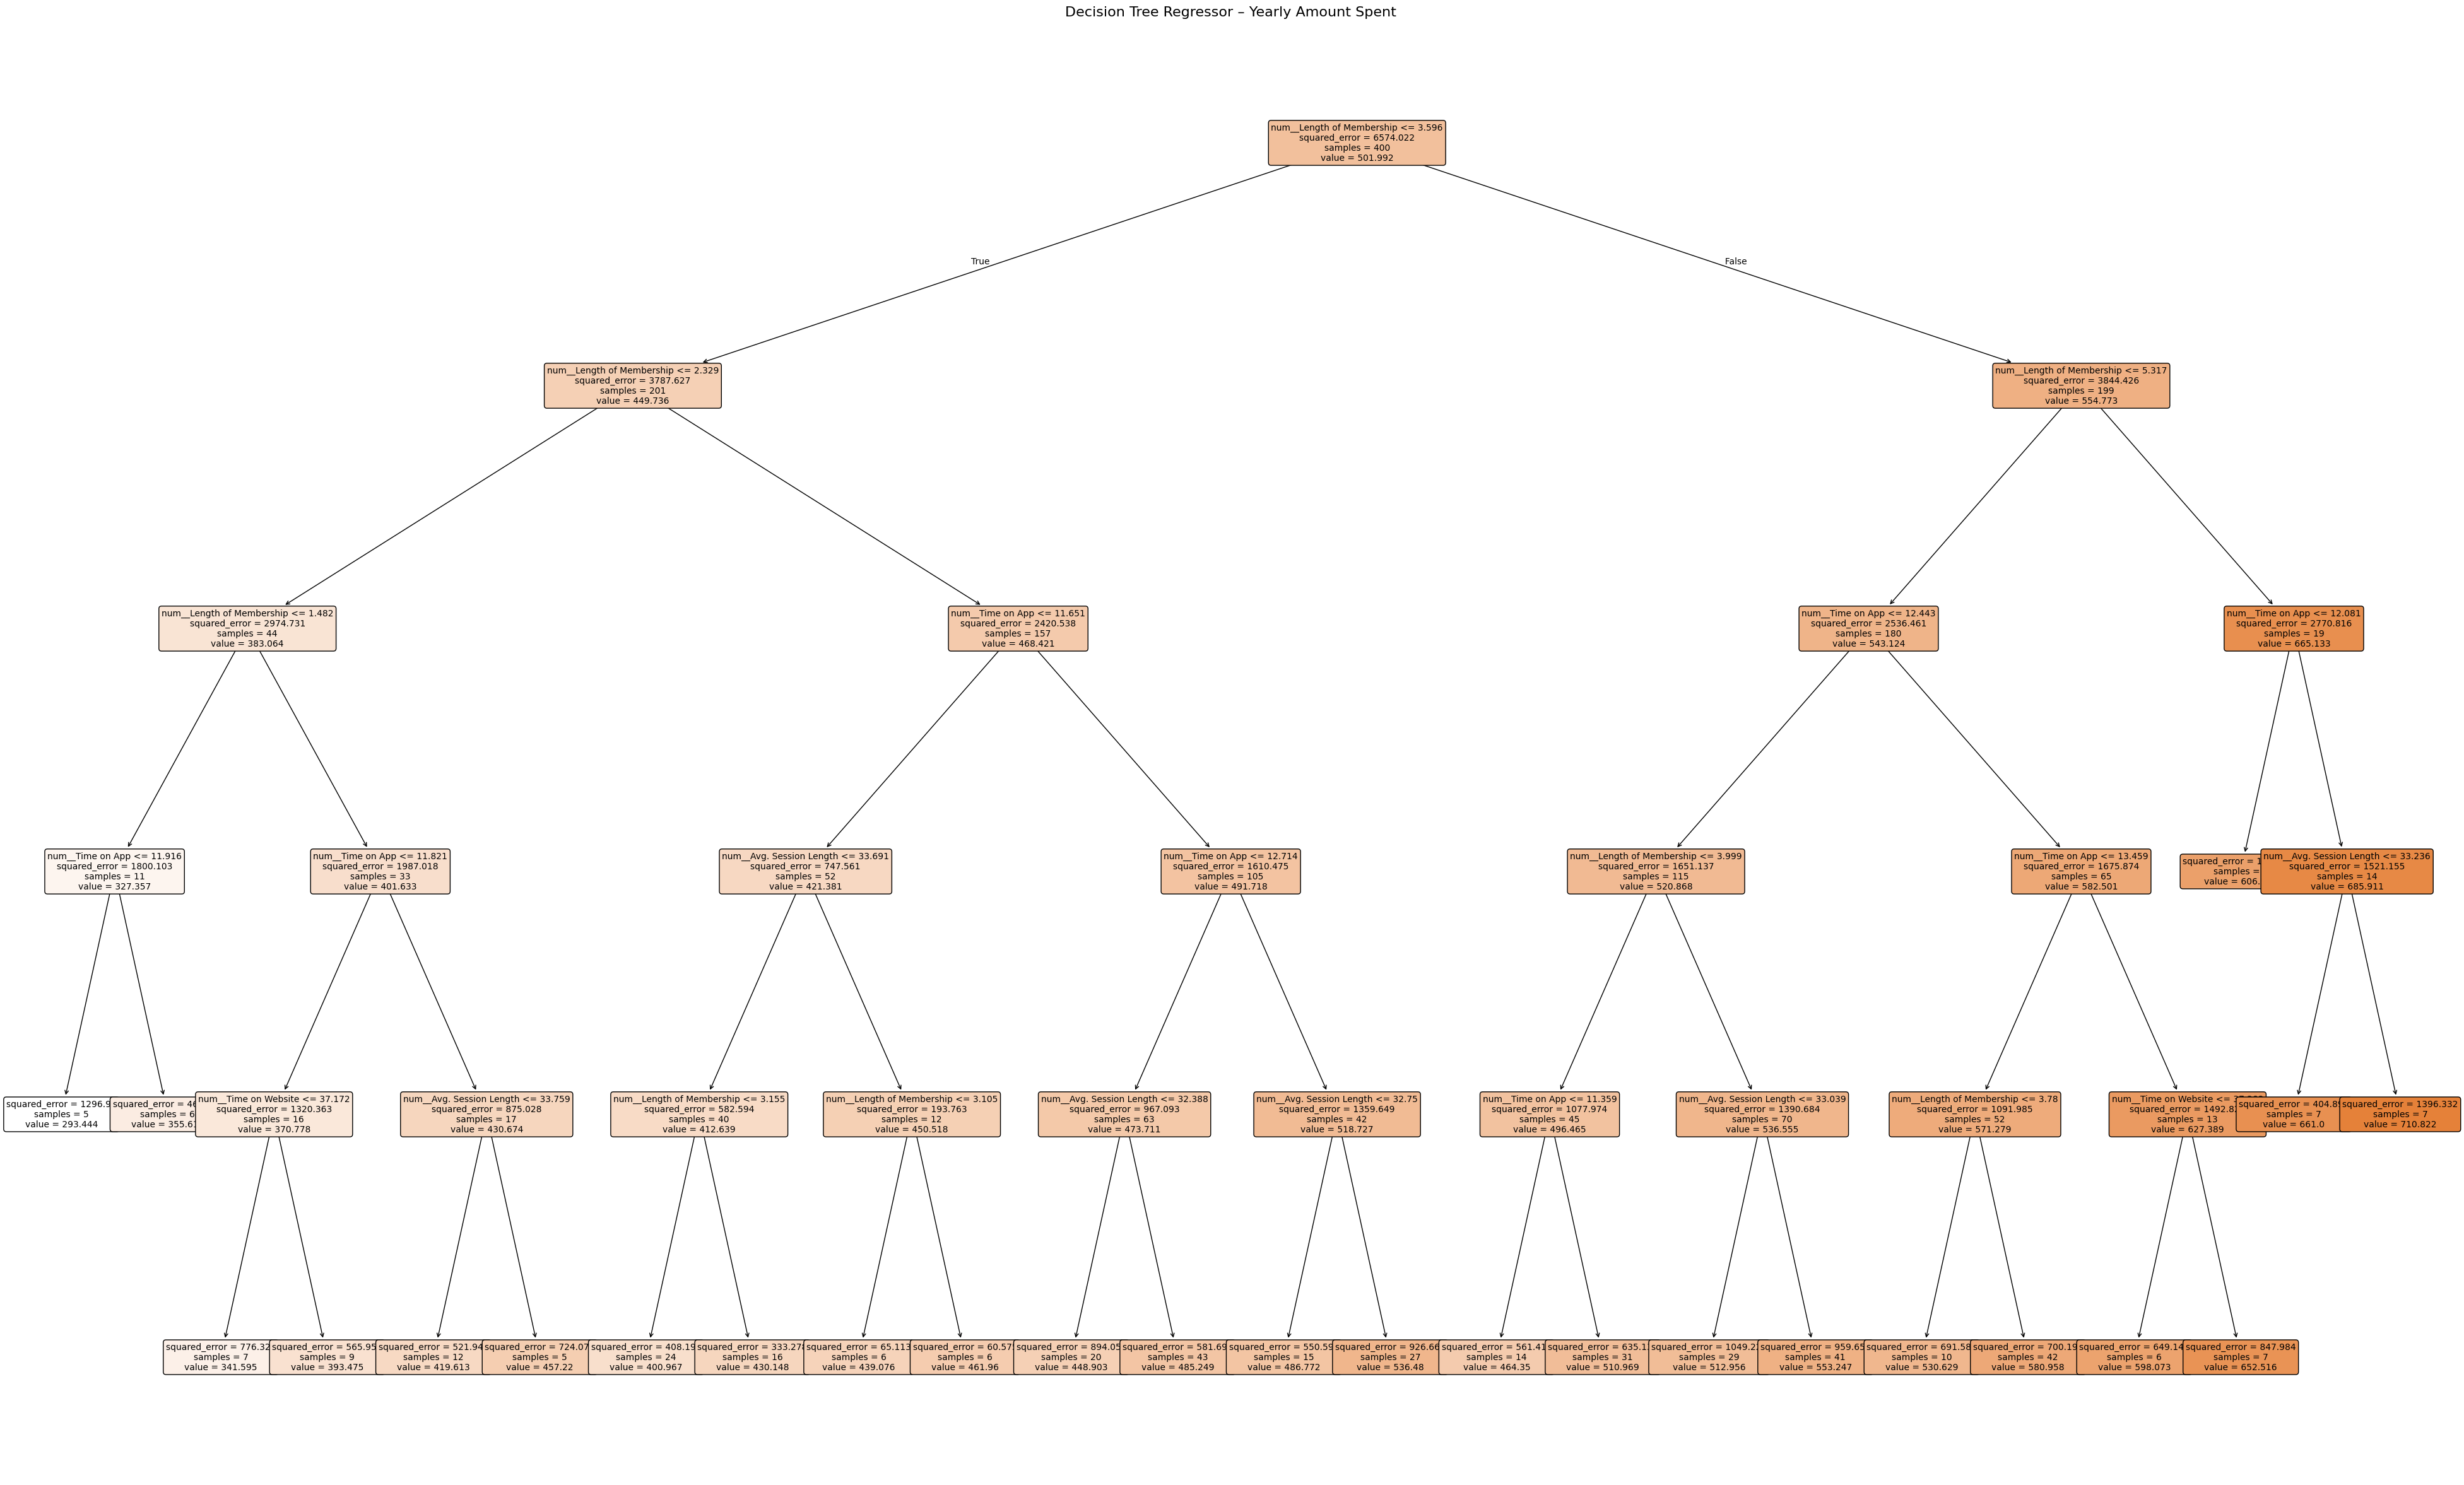

In [18]:
# Extract trained tree
trained_tree = model.named_steps["decision_tree"]

# Get feature names after one-hot encoding
feature_names = (
    model.named_steps["preprocessor"]
    .get_feature_names_out()
)

plt.figure(figsize=(50, 30))

plot_tree(
    trained_tree,
    feature_names=feature_names,
    filled=True,          # 🎨 MULTI-COLOR NODES
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Regressor – Yearly Amount Spent", fontsize=16)
plt.show()


In [19]:
new_customer = pd.DataFrame({
    "Avatar": ["Violet"],
    "Avg. Session Length": [34.49726773],
    "Time on App": [12.65565115],
    "Time on Website": [39.57766802],
    "Length of Membership": [4.082620633]
})

prediction = model.predict(new_customer)
print("Predicted Yearly Amount Spent:", prediction[0])


Predicted Yearly Amount Spent: 580.958002552381


In [20]:
# Extract trained decision tree
tree = model.named_steps["decision_tree"]

# Get feature names after preprocessing
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

# Get importance values
importances = tree.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df


,Feature,Importance
136,num__Length of Membership,0.737911
134,num__Time on App,0.212362
133,num__Avg. Session Length,0.041118
135,num__Time on Website,0.008609
4,cat__Avatar_Azure,0.000000
...,...,...
125,cat__Avatar_Tomato,0.000000
132,cat__Avatar_YellowGreen,0.000000
131,cat__Avatar_Yellow,0.000000
130,cat__Avatar_WhiteSmoke,0.000000


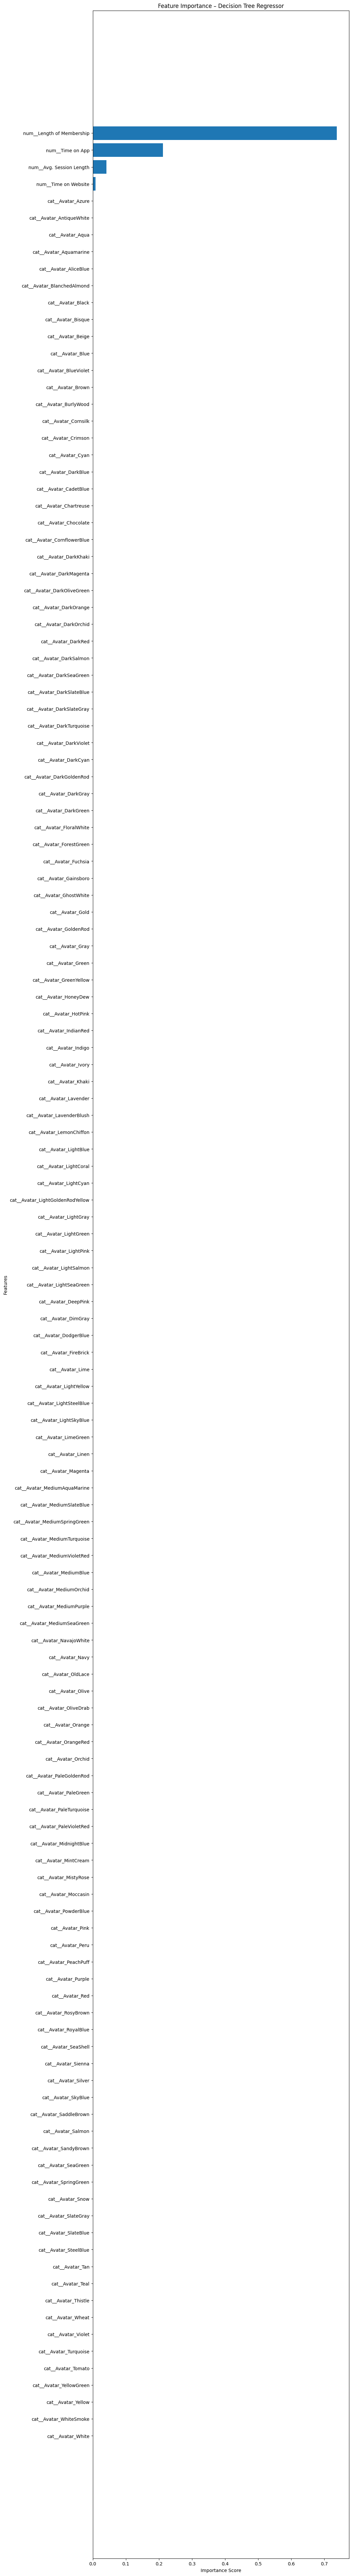

In [22]:
plt.figure(figsize=(10, 100))
plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance – Decision Tree Regressor")
plt.gca().invert_yaxis()
plt.show()


In [23]:
unknown_customer_1 = pd.DataFrame({
    "Avatar": ["Green"],
    "Avg. Session Length": [32.1],
    "Time on App": [10.2],
    "Time on Website": [37.8],
    "Length of Membership": [2.3]
})

prediction_1 = model.predict(unknown_customer_1)
print("Prediction for unknown customer 1:", prediction_1[0])


Prediction for unknown customer 1: 393.4752139111111


In [24]:
!git --version


git version 2.34.1


In [25]:
!git clone https://github.com/coder-Basundhara/Inhouse-training-projects


Cloning into 'Inhouse-training-projects'...


In [27]:
%cd /content
!git clone https://github.com/coder-Basundhara/Inhouse-training-projects.git repo



/content
Cloning into 'repo'...


In [28]:
!mv Inhouse-training-projects/* repo/


In [29]:
%cd repo


/content/repo


In [30]:
!git add .
!git commit -m "Added training projects"
!git push https://<USERNAME>:<TOKEN>@github.com/<USERNAME>/Inhouse-training-projects.git


Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@91701864083a.(none)')
/bin/bash: line 1: USERNAME: No such file or directory


In [ ]:
!git add .
!git commit -m "Added training projects"
!git push https://<USERNAME>:<TOKEN>@github.com/<USERNAME>/Inhouse-training-projects.git


In [31]:
%cd /content/Inhouse-training-projects

# Stage files
!git add .

# First commit
!git commit -m "Initial commit"


/content/Inhouse-training-projects
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@91701864083a.(none)')


In [32]:
!git config --global user.name "Basundhara Bera"
!git config --global user.email "basundhara.official@gmail.com"


In [33]:
!git config --global --list


user.name=Basundhara Bera
user.email=basundhara.official@gmail.com


In [34]:
%cd /content/Inhouse-training-projects

# Stage files
!git add .

# First commit
!git commit -m "Initial commit"


/content/Inhouse-training-projects
On branch main

Initial commit

nothing to commit (create/copy files and use "git add" to track)


In [35]:
%cd /content/Inhouse-training-projects


/content/Inhouse-training-projects


In [36]:
!git add .


In [37]:
!git add InhouseIntershipselfproject.ipynb


fatal: pathspec 'InhouseIntershipselfproject.ipynb' did not match any files


In [38]:
!ls


In [39]:
!git add C:\Users\HP\Downloads\InhouseIntershipselfproject.ipynb

fatal: pathspec 'C:UsersHPDownloadsInhouseIntershipselfproject.ipynb' did not match any files


In [40]:
!mv /content/InhouseIntershipselfproject.ipynb /content/Inhouse-training-projects/
%cd /content/Inhouse-training-projects


mv: cannot stat '/content/InhouseIntershipselfproject.ipynb': No such file or directory
/content/Inhouse-training-projects
